In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df.shape

(10000, 3)

C:\Users\Khalid\AppData\Local\Temp\ipykernel_244\3368598230.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])
C:\Users\Khalid\AppData\Local\Temp\ipykernel_244\3368598230.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

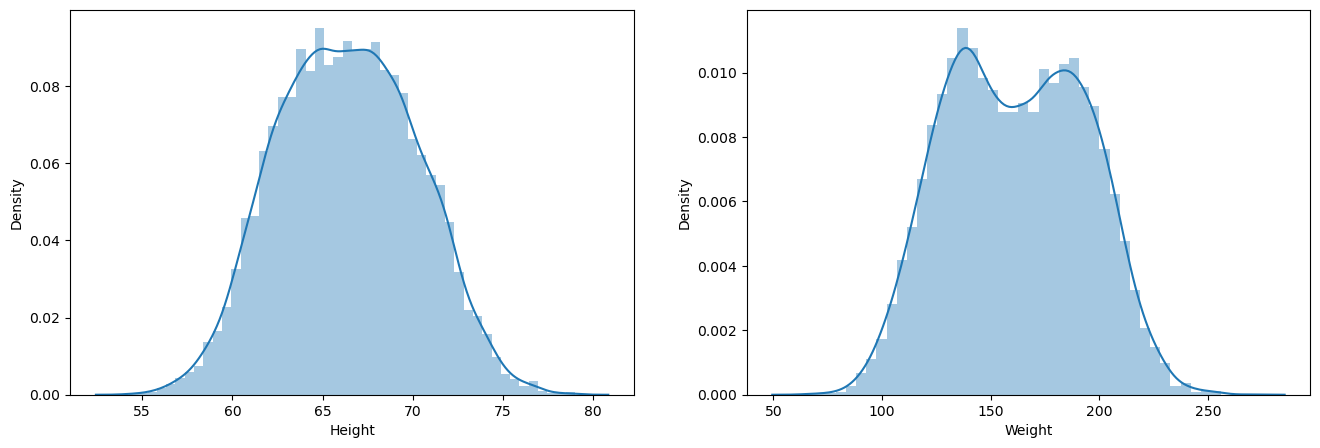

In [9]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['Height'])

plt.subplot(1,2,2)
sns.distplot(df['Weight'])

<Axes: ylabel='Weight'>

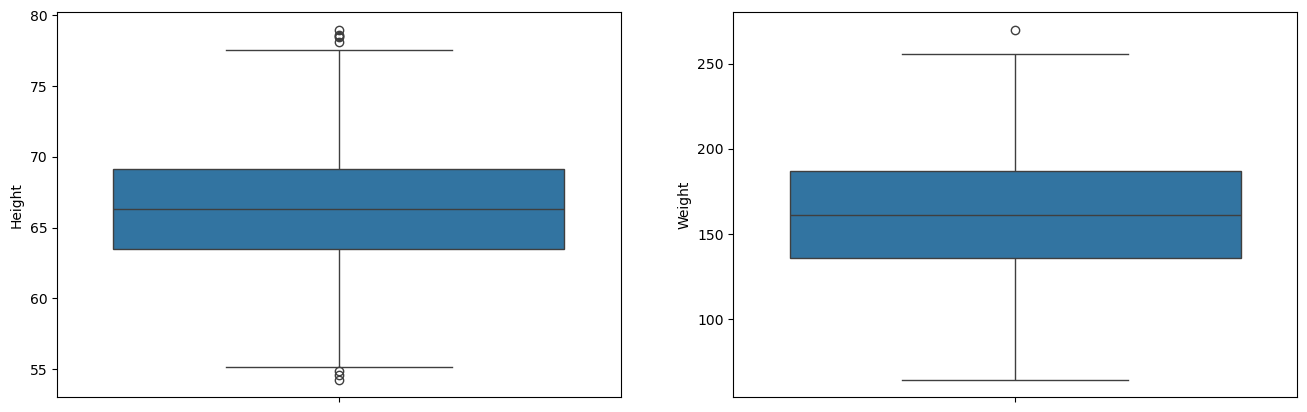

In [10]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.boxplot(df['Height'])

plt.subplot(1,2,2)
sns.boxplot(df['Weight'])

#### Most Outlier in Height column So we use Height column

In [11]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

### Now we put Cut on both side and Cut will be same 

In [12]:
upper_limit=df['Height'].quantile(0.99)
lower_limit=df['Height'].quantile(0.01)

In [14]:
upper_limit

74.7857900583366

In [15]:
lower_limit

58.13441158671655

### Check Outlier in Height Column 

In [18]:
df[(df['Height'] >= upper_limit) | (df['Height'] <= lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# 1 Trimming 
### Remove this Outliers

In [19]:
new_df_tri=df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [20]:
new_df_tri

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


### Before and After Describe()

In [21]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [22]:
new_df_tri['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

## Outlier check in Boxplot

Text(0.5, 1.0, 'After')

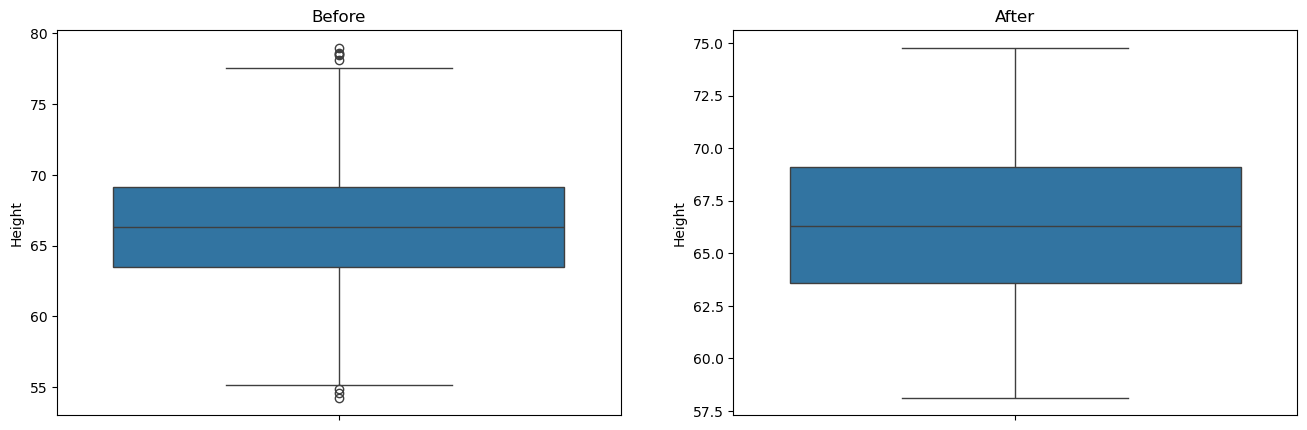

In [41]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.boxplot(df['Height'])
plt.title('Before')
plt.subplot(1,2,2)
sns.boxplot(new_df_tri['Height'])
plt.title('After')

# 2 Capping

In [32]:
new_df_cap=df.copy()

In [33]:
new_df_cap['Height']=np.where(
    df['Height'] >= upper_limit,
    upper_limit,
    np.where(df['Height'] <= lower_limit,
    lower_limit,
    df['Height']
    )
)

In [34]:
new_df_cap

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [35]:
new_df_cap.shape

(10000, 3)

In [36]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [37]:
new_df_cap['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

### Outlier check in Boxplot

Text(0.5, 1.0, 'After')

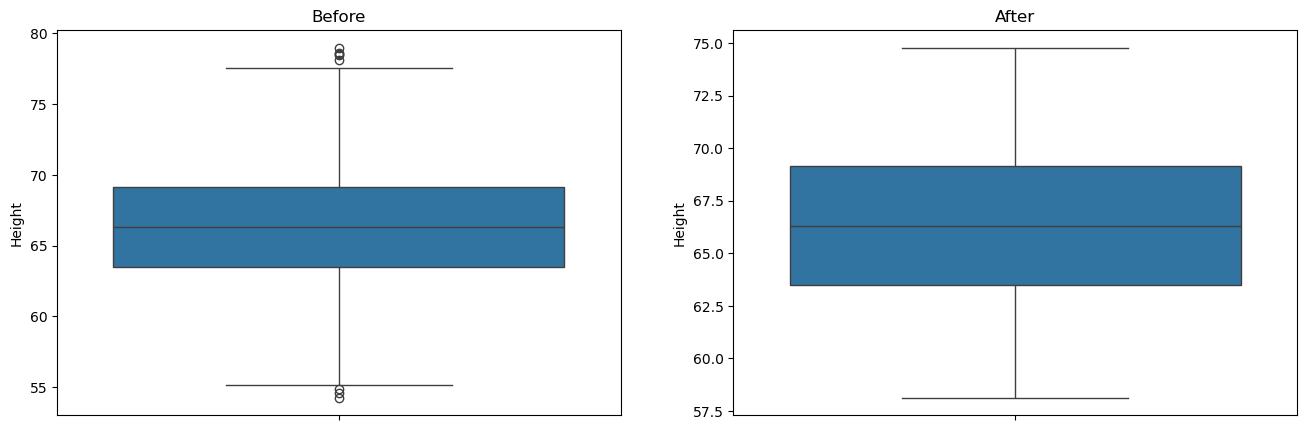

In [39]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.boxplot(df['Height'])
plt.title('Before')
plt.subplot(1,2,2)
sns.boxplot(new_df_cap['Height'])
plt.title('After')